In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import glob
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
import shap
import warnings
warnings.filterwarnings('ignore')

TITLE_SIZE = 14
LABEL_SIZE = 12
TICK_SIZE  = 10
DPI        = 300

# ── Load base merged dataset (from 03-model.ipynb) ────────────────────────────
base = pd.read_csv('../data/processed/merged_gbd_gdp_2021.csv')
print(f'Base dataset: {base.shape[0]} countries')
print(base[['location_name', 'Country Code', 'val', 'log_gdp', 'residual']].head(5).to_string(index=False))

Base dataset: 166 countries
location_name Country Code       val  log_gdp  residual
     Thailand          THA 34.472342 9.915553 13.652980
  Philippines          PHL 15.952341 9.089053  1.286076
  Timor-Leste          TLS 12.331008 8.828354 -0.394421
    Indonesia          IDN 20.391509 9.453841  3.009480
     Viet Nam          VNM 19.874778 9.396729  2.917937


In [2]:
# ── Load Modality 6: Aging (World Bank SP.POP.65UP.TO.ZS) ─────────────────────
aging_csv = glob.glob('../data/raw/aging_65plus/API_SP*.csv')[0]
aging_raw = pd.read_csv(aging_csv, skiprows=4)

aging = aging_raw[['Country Code', '2021']].dropna(subset=['2021']).copy()
aging.columns = ['Country Code', 'pct_65plus']
print(f'Aging data: {len(aging)} countries')

# ── Load Modality 8: Obesity (WHO GHO NCD_BMI_30C, 2016) ──────────────────────
obesity_raw = pd.read_csv('../data/raw/who_obesity_2016.csv')
obesity = obesity_raw[['SpatialDim', 'NumericValue']].copy()
obesity.columns = ['Country Code', 'obesity_pct']
print(f'Obesity data: {len(obesity)} countries')

# ── Load Modality 4: FAO Food Balance Sheets (2021, kcal/cap/day) ─────────────
fao_files = glob.glob('../data/raw/FAOSTAT*.csv')
fao_raw   = pd.read_csv(fao_files[0])

# Pivot: long → wide (one row per country, one column per item)
fao_pivot = fao_raw.pivot_table(
    index='Area',
    columns='Item',
    values='Value',
    aggfunc='first'
).reset_index()
fao_pivot.columns.name = None

# Composite dietary variables (kcal/capita/day, higher = more dietary purine load)
meat_items = ['Bovine Meat', 'Mutton & Goat Meat', 'Pigmeat', 'Poultry Meat', 'Meat, Other']
fish_items = ['Demersal Fish', 'Freshwater Fish', 'Marine Fish, Other', 'Pelagic Fish']
alc_item   = 'Beverages, Alcoholic'

fao_pivot['meat_kcal']    = fao_pivot[[c for c in meat_items if c in fao_pivot.columns]].sum(axis=1)
fao_pivot['seafood_kcal'] = fao_pivot[[c for c in fish_items if c in fao_pivot.columns]].sum(axis=1)
fao_pivot['alcohol_kcal'] = fao_pivot[alc_item] if alc_item in fao_pivot.columns else 0.0

fao_diet = fao_pivot[['Area', 'meat_kcal', 'seafood_kcal', 'alcohol_kcal']].copy()
print(f'FAO dietary data: {len(fao_diet)} countries')
print(fao_diet[['meat_kcal','seafood_kcal','alcohol_kcal']].describe().round(1))

Aging data: 265 countries
Obesity data: 199 countries


FAO dietary data: 177 countries
       meat_kcal  seafood_kcal  alcohol_kcal
count      177.0         177.0         177.0
mean       248.3          33.8          23.7
std        147.4          28.2          27.7
min         16.0           0.8           0.0
25%        129.4          13.3           3.1
50%        245.9          25.7          14.0
75%        347.7          48.2          33.9
max        812.2         152.4         155.2


In [3]:
# ── Name harmonisation: GBD names → FAO names ─────────────────────────────────
# FAO uses full official names; GBD uses shorter common names.
# Without this fix, countries including UK and USA silently drop from M5.
fao_name_map = {
    'United Kingdom':   'United Kingdom of Great Britain and Northern Ireland',
    'United States':    'United States of America',
    'Iran':             'Iran (Islamic Republic of)',
    'Bolivia':          'Bolivia (Plurinational State of)',
    'Venezuela':        'Venezuela (Bolivarian Republic of)',
    'Tanzania':         'United Republic of Tanzania',
    'South Korea':      'Republic of Korea',
    'North Korea':      "Democratic People's Republic of Korea",
    'Moldova':          'Republic of Moldova',
    'Russia':           'Russian Federation',
    'Vietnam':          'Viet Nam',
    'Syria':            'Syrian Arab Republic',
    'Laos':             "Lao People's Democratic Republic",
}
base['fao_name'] = base['location_name'].map(fao_name_map).fillna(base['location_name'])

# ── Merge all modalities ───────────────────────────────────────────────────────
merged = base.merge(aging,   on='Country Code', how='left')
merged = merged.merge(obesity, on='Country Code', how='left')
merged = merged.merge(fao_diet, left_on='fao_name', right_on='Area', how='left')
merged = merged.drop(columns=['Area', 'fao_name'], errors='ignore')

print('After merging all modalities:')
print(f'  Total rows:              {len(merged)}')
print(f'  pct_65plus available:    {merged["pct_65plus"].notna().sum()}')
print(f'  obesity_pct available:   {merged["obesity_pct"].notna().sum()}')
print(f'  meat_kcal available:     {merged["meat_kcal"].notna().sum()}')
print(f'  seafood_kcal available:  {merged["seafood_kcal"].notna().sum()}')
print(f'  alcohol_kcal available:  {merged["alcohol_kcal"].notna().sum()}')

# Spot-check: Georgia (main outlier) and UK (newly fixed)
for country in ['Georgia', 'United Kingdom']:
    row = merged[merged['location_name'] == country]
    if not row.empty:
        r = row.iloc[0]
        print(f'\n{country}: DALY={r["val"]:.1f}, M1-residual={r["residual"]:.1f}, '
              f'meat={r["meat_kcal"]:.1f}, alcohol={r["alcohol_kcal"]:.2f}')

After merging all modalities:
  Total rows:              166
  pct_65plus available:    166
  obesity_pct available:   165
  meat_kcal available:     149
  seafood_kcal available:  149
  alcohol_kcal available:  149

Georgia: DALY=77.2, M1-residual=56.9, meat=159.8, alcohol=4.92

United Kingdom: DALY=33.5, M1-residual=5.8, meat=375.3, alcohol=11.18


In [4]:
# ── Progressive regression: compare R² as we add modalities ───────────────────
results = []

model_specs = [
    ('M1: GDP only (baseline)',                          ['log_gdp']),
    ('M2: GDP + Aging',                                  ['log_gdp', 'pct_65plus']),
    ('M3: GDP + Aging + Obesity',                        ['log_gdp', 'pct_65plus', 'obesity_pct']),
    ('M4: GDP + Aging + Alcohol',                        ['log_gdp', 'pct_65plus', 'alcohol_kcal']),
    ('M5: GDP + Aging + Alcohol + Meat + Seafood',       ['log_gdp', 'pct_65plus', 'alcohol_kcal',
                                                          'meat_kcal', 'seafood_kcal']),
]

for name, features in model_specs:
    df_m = merged[features + ['val']].dropna()
    X = df_m[features]
    y = df_m['val']
    m = LinearRegression().fit(X, y)
    r2 = m.score(X, y)
    n = len(df_m)
    results.append({'Model': name, 'N countries': n, 'R²': round(r2, 3)})
    print(f'{name}')
    print(f'  N={n}, R²={r2:.3f}')
    for feat, coef in zip(features, m.coef_):
        print(f'  {feat}: {coef:.3f}')
    print()

results_df = pd.DataFrame(results)
print(results_df[['Model', 'N countries', 'R²']].to_string(index=False))

M1: GDP only (baseline)
  N=166, R²=0.386
  log_gdp: 7.445

M2: GDP + Aging
  N=166, R²=0.476
  log_gdp: 3.863
  pct_65plus: 0.854

M3: GDP + Aging + Obesity
  N=165, R²=0.472
  log_gdp: 3.599
  pct_65plus: 0.862
  obesity_pct: 0.047

M4: GDP + Aging + Alcohol
  N=149, R²=0.495
  log_gdp: 3.611
  pct_65plus: 1.076
  alcohol_kcal: -0.106



M5: GDP + Aging + Alcohol + Meat + Seafood
  N=149, R²=0.508
  log_gdp: 2.917
  pct_65plus: 1.071
  alcohol_kcal: -0.106
  meat_kcal: 0.007
  seafood_kcal: 0.043

                                     Model  N countries    R²
                   M1: GDP only (baseline)          166 0.386
                           M2: GDP + Aging          166 0.476
                 M3: GDP + Aging + Obesity          165 0.472
                 M4: GDP + Aging + Alcohol          149 0.495
M5: GDP + Aging + Alcohol + Meat + Seafood          149 0.508


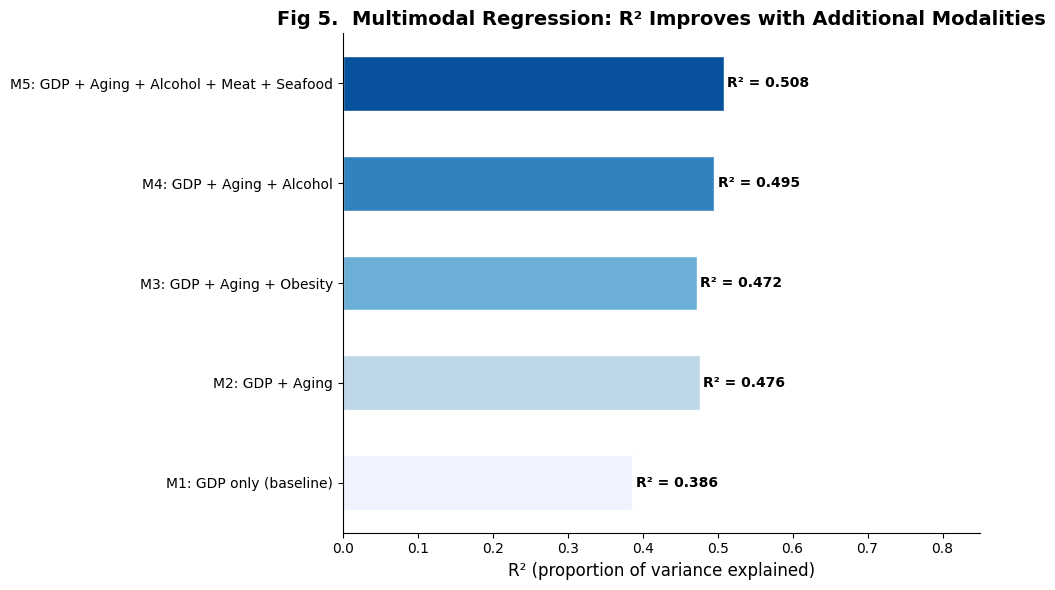

Saved: figures/fig5_r2_progression.png


In [5]:
# ── Fig 5: R² progression bar chart ───────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))

labels   = [r['Model'] for r in results]
r2_vals  = [r['R²']    for r in results]
colors   = ['#eff3ff', '#bdd7e7', '#6baed6', '#3182bd', '#08519c']

bars = ax.barh(labels, r2_vals, color=colors, edgecolor='white', height=0.55)
for bar, val in zip(bars, r2_vals):
    ax.text(val + 0.005, bar.get_y() + bar.get_height() / 2,
            f'R² = {val:.3f}', va='center', fontsize=TICK_SIZE, fontweight='bold')

ax.set_xlabel('R² (proportion of variance explained)', fontsize=LABEL_SIZE)
ax.set_title('Fig 5.  Multimodal Regression: R² Improves with Additional Modalities',
             fontsize=TITLE_SIZE, fontweight='bold')
ax.set_xlim(0, 0.85)
ax.tick_params(labelsize=TICK_SIZE)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('../figures/fig5_r2_progression.png', dpi=DPI, bbox_inches='tight')
plt.show()
print('Saved: figures/fig5_r2_progression.png')

In [6]:
# ── Best model: GDP + Aging + Alcohol + Meat + Seafood (M5) ───────────────────
best_features = ['log_gdp', 'pct_65plus', 'alcohol_kcal', 'meat_kcal', 'seafood_kcal']
df_best = merged[best_features + ['val', 'location_name']].dropna().copy()

X_best = df_best[best_features]
y_best = df_best['val']

model_best = LinearRegression().fit(X_best, y_best)
df_best['predicted_multi'] = model_best.predict(X_best)
df_best['residual_multi']  = df_best['val'] - df_best['predicted_multi']

print(f'Best model R²:  {model_best.score(X_best, y_best):.3f}')
print(f'Baseline R²:    0.386')
print(f'R² improvement: +{model_best.score(X_best, y_best) - 0.386:.3f}')

# How much of Georgia residual does the full dietary model explain?
geo_multi = df_best[df_best['location_name'] == 'Georgia']
if not geo_multi.empty:
    gdp_pred  = merged.loc[merged['location_name'] == 'Georgia', 'predicted'].values
    gdp_resid = merged.loc[merged['location_name'] == 'Georgia', 'residual'].values
    print(f'\nGeorgia:')
    print(f'  Actual DALY rate:           {geo_multi["val"].values[0]:.1f}')
    if len(gdp_pred):
        print(f'  GDP-only prediction:        {gdp_pred[0]:.1f}')
        print(f'  Residual (GDP only):        {gdp_resid[0]:.1f}')
    print(f'  M5 multimodal prediction:   {geo_multi["predicted_multi"].values[0]:.1f}')
    print(f'  Residual (M5 multimodal):   {geo_multi["residual_multi"].values[0]:.1f}')
else:
    print('Georgia not in M5 sample (missing dietary data)')

Best model R²:  0.508
Baseline R²:    0.386
R² improvement: +0.122

Georgia:
  Actual DALY rate:           77.2
  GDP-only prediction:        20.3
  Residual (GDP only):        56.9
  M5 multimodal prediction:   25.5
  Residual (M5 multimodal):   51.7


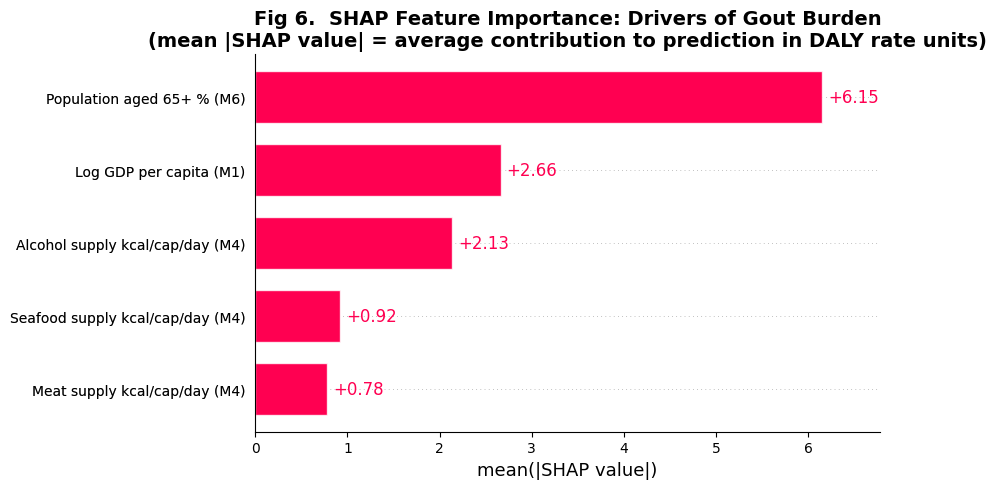

Saved: figures/fig6_shap.png


In [7]:
# ── SHAP: feature importance for the best model ────────────────────────────────
explainer   = shap.LinearExplainer(model_best, X_best)
shap_values = explainer(X_best)

fig, ax = plt.subplots(figsize=(9, 5))
shap.plots.bar(shap_values, show=False, ax=ax)

ax.set_title('Fig 6.  SHAP Feature Importance: Drivers of Gout Burden\n'
             '(mean |SHAP value| = average contribution to prediction in DALY rate units)',
             fontsize=TITLE_SIZE, fontweight='bold')
ax.tick_params(labelsize=TICK_SIZE)

labels_map = {
    'log_gdp':       'Log GDP per capita (M1)',
    'pct_65plus':    'Population aged 65+ % (M6)',
    'obesity_pct':   'Adult obesity prevalence % (M8)',
    'alcohol_kcal':  'Alcohol supply kcal/cap/day (M4)',
    'meat_kcal':     'Meat supply kcal/cap/day (M4)',
    'seafood_kcal':  'Seafood supply kcal/cap/day (M4)',
}
ax.set_yticklabels([labels_map.get(t.get_text(), t.get_text())
                    for t in ax.get_yticklabels()], fontsize=TICK_SIZE)

plt.tight_layout()
plt.savefig('../figures/fig6_shap.png', dpi=DPI, bbox_inches='tight')
plt.show()
print('Saved: figures/fig6_shap.png')

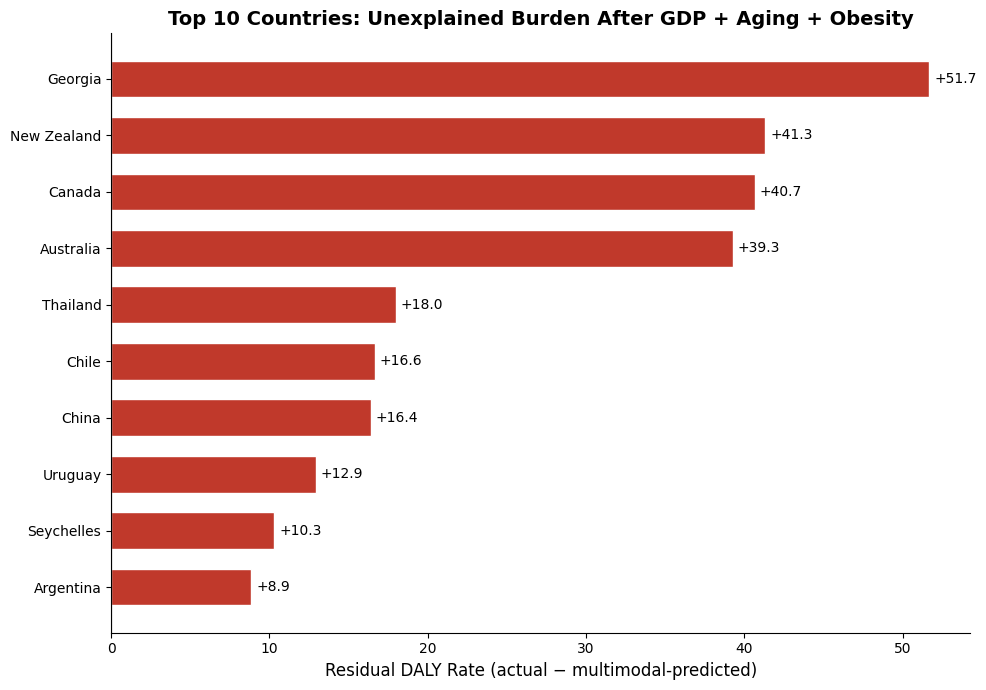

Saved: figures/fig7_residuals_multi.png

Top 10 unexplained countries (multimodal model):
location_name       val  predicted_multi  residual_multi
      Georgia 77.167718        25.494469       51.673249
  New Zealand 72.894783        31.574535       41.320248
       Canada 74.989477        34.320728       40.668749
    Australia 68.073227        28.807629       39.265598
     Thailand 34.472342        16.484558       17.987785
        Chile 39.864585        23.218382       16.646203
        China 37.039277        20.618344       16.420932
      Uruguay 39.567977        26.637456       12.930521
   Seychelles 27.837153        17.530509       10.306644
    Argentina 33.277918        24.415324        8.862593


In [8]:
# ── Remaining residuals after multimodal model ─────────────────────────────────
top10_multi = df_best.nlargest(10, 'residual_multi').sort_values('residual_multi')

fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(top10_multi['location_name'], top10_multi['residual_multi'],
               color='#c0392b', edgecolor='white', height=0.65)
for bar, val in zip(bars, top10_multi['residual_multi']):
    ax.text(val + 0.3, bar.get_y() + bar.get_height() / 2,
            f'+{val:.1f}', va='center', fontsize=TICK_SIZE)

ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Residual DALY Rate (actual \u2212 multimodal-predicted)', fontsize=LABEL_SIZE)
ax.set_title('Top 10 Countries: Unexplained Burden After GDP + Aging + Obesity',
             fontsize=TITLE_SIZE, fontweight='bold')
ax.tick_params(labelsize=TICK_SIZE)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('../figures/fig7_residuals_multi.png', dpi=DPI, bbox_inches='tight')
plt.show()
print('Saved: figures/fig7_residuals_multi.png')

print('\nTop 10 unexplained countries (multimodal model):')
print(df_best.nlargest(10, 'residual_multi')[['location_name','val','predicted_multi','residual_multi']]
      .sort_values('residual_multi', ascending=False).to_string(index=False))

In [9]:
# ── Fig 8: Choropleth — M5 residuals by country ────────────────────────────────
# Countries coloured by how far their gout DALY rate lies above or below the
# M5 model prediction. Red = under-treated relative to model; blue = over-predicted.
# Grey = country not in M5 sample (missing FAO dietary data).

# ── 1. Build the map dataframe ─────────────────────────────────────────────────
df_map = (
    df_best[['location_name', 'residual_multi']]
    .merge(merged[['location_name', 'Country Code']], on='location_name', how='left')
    .rename(columns={'Country Code': 'iso3', 'residual_multi': 'residual'})
)

abs_max = df_map['residual'].abs().max()   # symmetric scale centred at 0
print(f'Countries in map: {len(df_map)}')
print(f'Residual range:   {df_map["residual"].min():.1f} to {df_map["residual"].max():.1f}')

# ── 2. Plot with plotly (preferred — clean built-in world geometry) ─────────────
try:
    import plotly.express as px

    fig_map = px.choropleth(
        df_map,
        locations='iso3',
        color='residual',
        hover_name='location_name',
        color_continuous_scale='RdBu_r',
        range_color=[-abs_max, abs_max],
        labels={'residual': 'Residual (DALY/100k)'},
    )
    fig_map.update_layout(
        title=dict(
            text='<b>Fig 8. Gout DALY Rate Residuals after Full Multimodal Adjustment (M5)</b><br>'
                 '<sup>Red = higher burden than predicted &nbsp;|&nbsp; '
                 'Blue = lower burden than predicted &nbsp;|&nbsp; Grey = no data</sup>',
            x=0.5, xanchor='center', font=dict(size=14),
        ),
        coloraxis_colorbar=dict(
            title='Residual<br>(DALY/100k)',
            len=0.55, thickness=15,
        ),
        margin=dict(l=0, r=0, t=90, b=0),
        geo=dict(
            showframe=False,
            showcoastlines=True,
            coastlinecolor='lightgray',
            landcolor='#f5f5f5',
            projection_type='natural earth',
        ),
        width=1400, height=680,
    )

    # Try PNG export (requires kaleido: pip install kaleido)
    try:
        fig_map.write_image('../figures/fig8_choropleth.png', scale=2)
        print('Saved: figures/fig8_choropleth.png')
    except Exception as e_img:
        # Fallback: save as interactive HTML
        fig_map.write_html('../figures/fig8_choropleth.html')
        print(f'kaleido not installed ({e_img}).')
        print('Saved as HTML: figures/fig8_choropleth.html')
        print('To enable PNG export:  pip install kaleido')

    fig_map.show()

# ── 3. Geopandas fallback (if plotly not installed) ────────────────────────────
except ImportError:
    print('plotly not found — falling back to geopandas + matplotlib.')
    print('For a nicer map, install plotly:  pip install plotly kaleido\n')

    try:
        import geopandas as gpd
        from matplotlib.colors import TwoSlopeNorm

        # Load world geometry (try geodatasets first, then legacy API)
        try:
            from geodatasets import get_path as _gp
            world = gpd.read_file(_gp('naturalearth.land'))
        except Exception:
            world = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))

        world_m = world.merge(df_map, left_on='iso_a3', right_on='iso3', how='left')

        fig, ax = plt.subplots(figsize=(18, 9))
        norm = TwoSlopeNorm(vmin=-abs_max, vcenter=0, vmax=abs_max)

        world_m.plot(
            column='residual', ax=ax,
            cmap='RdBu_r', norm=norm,
            missing_kwds={'color': '#d9d9d9', 'label': 'No data'},
            legend=True,
            legend_kwds={'label': 'Residual (DALY/100k)', 'shrink': 0.45},
        )
        ax.set_title(
            'Fig 8.  Gout DALY Rate Residuals after Full Multimodal Adjustment (M5)\n'
            'Red = higher burden than predicted  |  Blue = lower  |  Grey = no data',
            fontsize=TITLE_SIZE, fontweight='bold',
        )
        ax.axis('off')
        plt.tight_layout()
        plt.savefig('../figures/fig8_choropleth.png', dpi=DPI, bbox_inches='tight')
        plt.show()
        print('Saved: figures/fig8_choropleth.png')

    except ImportError:
        print('geopandas not found either.')
        print('Install one of:')
        print('  pip install plotly kaleido')
        print('  pip install geopandas geodatasets')

Countries in map: 153
Residual range:   -15.4 to 51.7


Resorting to unclean kill browser.


kaleido not installed (Command '['taskkill', '/F', '/T', '/PID', '7156']' timed out after 6 seconds).
Saved as HTML: figures/fig8_choropleth.html
To enable PNG export:  pip install kaleido
